# 🐾 Classification CNN — Dogs vs Cats
### EHTP — Module 06 Deep Learning

---

## ⚡ AVANT DE COMMENCER — 3 étapes obligatoires

### Étape 1 — Activer le GPU
> **Exécution → Modifier le type d'exécution → Accélérateur matériel → GPU (T4)**

### Étape 2 — Uploader le dataset sur Google Drive
> 1. Va sur [drive.google.com](https://drive.google.com)
> 2. Compresse le dossier `data_cats_and_dogs` en ZIP sur ton PC
> 3. Upload `data_cats_and_dogs.zip` dans **Mon Drive** (racine)

### Étape 3 — Exécuter toutes les cellules
> **Exécution → Tout exécuter** (ou `Ctrl+F9`)

---

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0 — Setup GPU & Google Drive

In [15]:
# Vérifier que le GPU est bien disponible
import tensorflow as tf

print(f"TensorFlow version : {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU détecté : {gpus[0].name}")
    !nvidia-smi --query-gpu=name,memory.total --format=csv,noheader
else:
    print("⚠️  Aucun GPU — va dans Exécution → Modifier le type d'exécution → GPU")

TensorFlow version : 2.20.0
✅ GPU détecté : /physical_device:GPU:0
Tesla T4, 15360 MiB


In [16]:
# Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive monté.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive monté.


In [17]:
import os, zipfile, gdown

# ── 1. Paramètres ───────────────────────────────────────────────────
FILE_ID     = '1_-Rdei3_SXQtRZ0b7pW88gCsh0PjyqnP'
ZIP_PATH    = '/content/data_cats_and_dogs.zip'
EXTRACT_DIR = '/content/'
DATA_DIR    = '/content/data_cats_and_dogs'

# ── 2. Téléchargement depuis Google Drive ───────────────────────────
if not os.path.exists(ZIP_PATH):
    print("⬇️ Téléchargement du dataset depuis Google Drive...")
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', ZIP_PATH, quiet=False)
    print("✅ Téléchargement terminé.")
else:
    print("✅ ZIP déjà téléchargé.")

# ── 3. Extraction ───────────────────────────────────────────────────
if not os.path.exists(DATA_DIR):
    print("📦 Extraction du dataset...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("✅ Dataset extrait.")
else:
    print("✅ Dataset déjà présent, pas besoin de ré-extraire.")

print("Contenu :", os.listdir(DATA_DIR))

✅ ZIP déjà téléchargé.
✅ Dataset déjà présent, pas besoin de ré-extraire.
Contenu : ['validation', 'train']


## 1 — Importer des librairies pertinentes

In [18]:
# Librairies système et données
import os
import random
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Traitement d'images
from PIL import Image

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Métriques scikit-learn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow : {tf.__version__} | NumPy : {np.__version__}")
print("✅ Toutes les librairies importées avec succès !")

TensorFlow : 2.20.0 | NumPy : 2.0.2
✅ Toutes les librairies importées avec succès !


## 2 — Localiser le path où se trouvent toutes les images

In [19]:
# Répertoire racine du dataset (Colab — extrait depuis Drive)
my_data_dir = '/content/data_cats_and_dogs'

### 2.1 — Vérifier que la commande ci-dessous retourne ['train', 'validation']

In [20]:
os.listdir(my_data_dir)

['validation', 'train']

### 2.2 — Définir les variables train_path et val_path

In [21]:
# Chemins train et validation
train_path = os.path.join(my_data_dir, 'train')
test_path  = os.path.join(my_data_dir, 'validation')
val_path   = test_path

print("train_path :", train_path)
print("val_path   :", val_path)

train_path : /content/data_cats_and_dogs/train
val_path   : /content/data_cats_and_dogs/validation


### 2.3 — Print le nombre d'images pour chaque class (cats & dogs)

In [22]:
# Comptage des images par classe
n_train_dogs = len(os.listdir(os.path.join(train_path, 'dogs')))
n_train_cats = len(os.listdir(os.path.join(train_path, 'cats')))
n_val_dogs   = len(os.listdir(os.path.join(val_path, 'dogs')))
n_val_cats   = len(os.listdir(os.path.join(val_path, 'cats')))

print(f"Train  — Dogs : {n_train_dogs} images")
print(f"Train  — Cats : {n_train_cats} images")
print(f"Val    — Dogs : {n_val_dogs} images")
print(f"Val    — Cats : {n_val_cats} images")

total = n_train_dogs + n_train_cats + n_val_dogs + n_val_cats
print(f"\nTotal : {total} images")

Train  — Dogs : 998 images
Train  — Cats : 998 images
Val    — Dogs : 500 images
Val    — Cats : 500 images

Total : 2996 images


## 3 — Analyse d'exemples d'images dogs and cats

### 3.1 — Choisir au hasard une image de dog dans le train_path

In [23]:
# Sélection aléatoire d'une image de chien
dog_files = os.listdir(os.path.join(train_path, 'dogs'))
dog_path  = os.path.join(train_path, 'dogs', random.choice(dog_files))
print("Image dog sélectionnée :", dog_path)

Image dog sélectionnée : /content/data_cats_and_dogs/train/dogs/dog.296.jpg


### 3.2 — Transformer cette image en numpy array

In [24]:
# Conversion en numpy array via PIL
dog_array = np.array(Image.open(dog_path))

### 3.3 — Vérifier les dimensions de cette image

In [25]:
# Affichage des dimensions (hauteur, largeur, canaux RGB)
print(f"Shape : {dog_array.shape}")
print(f"  Hauteur : {dog_array.shape[0]} px | Largeur : {dog_array.shape[1]} px | Canaux : {dog_array.shape[2]}")

Shape : (81, 99, 3)
  Hauteur : 81 px | Largeur : 99 px | Canaux : 3


### 3.4 — Plot cette image via 'imshow'

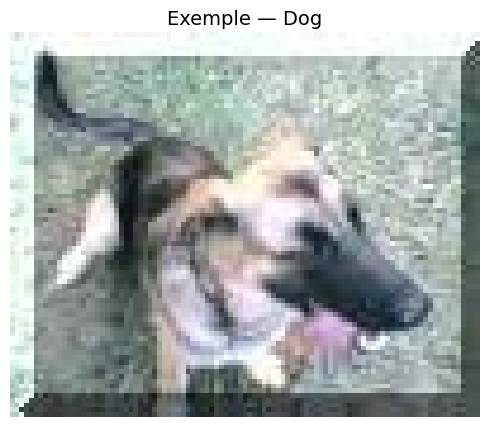

In [26]:
# Visualisation de l'image dog
plt.figure(figsize=(5, 5))
plt.imshow(dog_array)
plt.title('Exemple — Dog', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

### 3.5 — Refaire le même travail avec l'image d'un cat depuis le dossier train

Image cat : /content/data_cats_and_dogs/train/cats/cat.482.jpg
Shape     : (190, 500, 3)


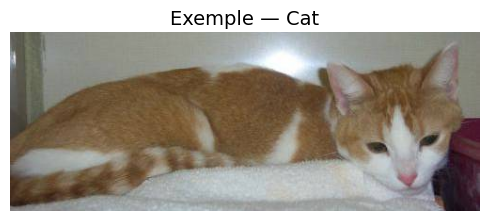

In [27]:
# Sélection aléatoire d'une image de chat et conversion en numpy array
cat_files = os.listdir(os.path.join(train_path, 'cats'))
cat_path  = os.path.join(train_path, 'cats', random.choice(cat_files))
cat_array = np.array(Image.open(cat_path))

print(f"Image cat : {cat_path}")
print(f"Shape     : {cat_array.shape}")

plt.figure(figsize=(5, 5))
plt.imshow(cat_array)
plt.title('Exemple — Cat', fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

## 4 — Créer un ImageDataGenerator

In [28]:
# ImageDataGenerator pour le train : normalisation + augmentations
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,       # Normalisation [0, 1]
    rotation_range=20,        # Rotation aléatoire ±20°
    width_shift_range=0.1,    # Décalage horizontal 10%
    height_shift_range=0.1,   # Décalage vertical 10%
    shear_range=0.1,          # Cisaillement
    zoom_range=0.1,           # Zoom aléatoire
    horizontal_flip=True,     # Miroir horizontal
    fill_mode='nearest'
)
print("✅ ImageDataGenerator (train) avec augmentation créé.")

✅ ImageDataGenerator (train) avec augmentation créé.


In [29]:
# ImageDataGenerator de base pour la validation : rescale uniquement
image_generator = ImageDataGenerator(rescale=1.0 / 255)
print("✅ ImageDataGenerator (validation) — rescale uniquement créé.")

✅ ImageDataGenerator (validation) — rescale uniquement créé.


## 5 — Construire un modèle CNN from scratch

**- Utiliser à minima les types layers suivants: Conv2D, MaxPooling2D, Dense.**

**- Utiliser également la technique du Dropout.**

**- Prendre un input_shape arbitraire fixe et approprié**

**- Print le model summary**

**- Ne pas hésiter à ajouter des techniques ou des méthodes sur les données ou le modèle pour améliorer la performance !**

**L'objectif est de maximiser l'accuracy sur les données de test**

In [30]:
# Constantes globales
IMG_SIZE   = (150, 150)
IMG_SHAPE  = (150, 150, 3)
BATCH_SIZE = 32

In [31]:
# Create the CNN model
# Architecture : 4 blocs Conv2D + MaxPooling, Flatten + Dense + Dropout + sigmoid
model = models.Sequential([
    # Bloc 1 — features bas niveau (bords, couleurs)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMG_SHAPE),
    layers.MaxPooling2D(2, 2),

    # Bloc 2 — features intermédiaires
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Bloc 3 — features de haut niveau
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Bloc 4 — approfondissement
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # Tête de classification
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),               # Régularisation anti-surapprentissage
    layers.Dense(1, activation='sigmoid')  # Sortie : 0=cat, 1=dog
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Créer une instance de EarlyStopping

In [32]:
# EarlyStopping : arrête l'entraînement si val_loss stagne pendant 5 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
print("✅ EarlyStopping créé (patience=5, monitor=val_loss).")

✅ EarlyStopping créé (patience=5, monitor=val_loss).


### 5.3 Créer un generator pour le train et validation set

In [33]:
# Create the train_image_generator
# Keras détecte automatiquement les classes depuis les sous-dossiers (cats/, dogs/)
train_image_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 1996 images belonging to 2 classes.


In [34]:
# Create the validation_image_generator
# shuffle=False : indispensable pour récupérer les vraies étiquettes dans l'ordre
val_image_generator = image_generator.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 1000 images belonging to 2 classes.


In [35]:
# verify the classes dictionary (1 is dog or cat ?)
# Keras trie par ordre alphabétique : cats=0, dogs=1
print("Dictionnaire des classes :", train_image_generator.class_indices)
print("→ 0 = cat  |  1 = dog")

Dictionnaire des classes : {'cats': 0, 'dogs': 1}
→ 0 = cat  |  1 = dog


### 5.3 Entraîner le modèle à partir du train_image_generator et utiliser le EarlyStopping

In [36]:
# Entraînement du modèle CNN from scratch
# suivre à la fois la loss, accuracy, val_loss et val_accuracy
history = model.fit(
    train_image_generator,
    epochs=30,
    validation_data=val_image_generator,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 32s 394ms/step - accuracy: 0.5276 - loss: 0.6936 - val_accuracy: 0.5750 - val_loss: 0.6859
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 261ms/step - accuracy: 0.5586 - loss: 0.6867 - val_accuracy: 0.5890 - val_loss: 0.6744
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - accuracy: 0.6092 - loss: 0.6628 - val_accuracy: 0.6560 - val_loss: 0.6266
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 281ms/step - accuracy: 0.6132 - loss: 0.6561 - val_accuracy: 0.6410 - val_loss: 0.6365
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 281ms/step - accuracy: 0.6458 - loss: 0.6349 - val_accuracy: 0.6730 - val_loss: 0.5869
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - accuracy: 0.6493 - loss: 0.6238 - val_accuracy: 0.6700 - val_loss: 0.6232
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 260ms/step - accuracy: 0.6683 - loss: 0.6082 - val_accuracy: 0.6860 - val_loss: 0.5782
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 256ms/step - accuracy: 0.6663 - loss: 0.6078 - val_accu

## 8 — Evaluation du modèle

### 8.1 Sauvegarder les losses dans un dataframe

In [37]:
# Sauvegarde de l'historique d'entraînement dans un DataFrame pandas
history_df = pd.DataFrame(history.history)
history_df.index.name = 'epoch'
history_df.head(10)

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
0,0.527555,0.693606,0.575,0.685914
1,0.558617,0.686657,0.589,0.674391
2,0.609218,0.662814,0.656,0.626585
3,0.613226,0.656090,0.641,0.636501
4,0.645792,0.634940,0.673,0.586935
5,0.649299,0.623807,0.670,0.623233
6,0.668337,0.608179,0.686,0.578194
7,0.666333,0.607800,0.688,0.568183
8,0.691884,0.585494,0.697,0.572313


### 8.2 Plot le training et validation loss

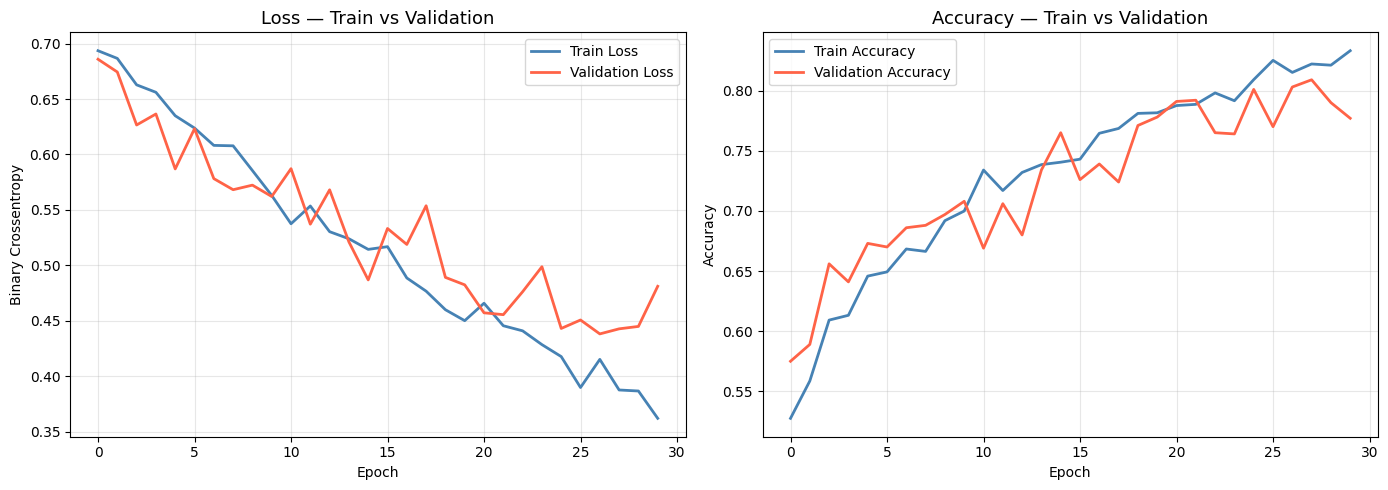

In [38]:
# Courbes d'apprentissage : loss et accuracy — train vs validation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1 — Loss
axes[0].plot(history_df['loss'],     label='Train Loss',      color='steelblue', linewidth=2)
axes[0].plot(history_df['val_loss'], label='Validation Loss', color='tomato',    linewidth=2)
axes[0].set_title('Loss — Train vs Validation', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Binary Crossentropy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Subplot 2 — Accuracy
axes[1].plot(history_df['accuracy'],     label='Train Accuracy',      color='steelblue', linewidth=2)
axes[1].plot(history_df['val_accuracy'], label='Validation Accuracy', color='tomato',    linewidth=2)
axes[1].set_title('Accuracy — Train vs Validation', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 8.3 Calculer les probabilités pour le validation image generator

In [39]:
# Réinitialiser le générateur avant la prédiction (important !)
val_image_generator.reset()

y_pred_proba = model.predict(val_image_generator, verbose=1)
print(f"Shape des probabilités : {y_pred_proba.shape}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step
Shape des probabilités : (1000, 1)


### 8.4 Transformer ces probabilités en classes en prenant un threshold de 0.5

In [40]:
# Threshold 0.5 : prob >= 0.5 → dog (1), sinon → cat (0)
y_pred_class = (y_pred_proba >= 0.5).astype(int).flatten()
print(f"Classes prédites (10 premiers) : {y_pred_class[:10]}")

Classes prédites (10 premiers) : [0 0 1 0 0 0 0 0 0 0]


### 8.5 Récupérer le vecteur des true labels à partir du validation image generator

In [41]:
# Vrais labels (shuffle=False garantit l'ordre correct)
y_test = val_image_generator.classes
print(f"Shape y_test : {y_test.shape}")
print(f"Vrais labels (10 premiers) : {y_test[:10]}")

Shape y_test : (1000,)
Vrais labels (10 premiers) : [0 0 0 0 0 0 0 0 0 0]


### 8.6 Afficher le classification report et la matrice de confusion

        Classification Report — CNN from scratch
              precision    recall  f1-score   support

         Cat       0.81      0.79      0.80       500
         Dog       0.80      0.82      0.81       500

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000



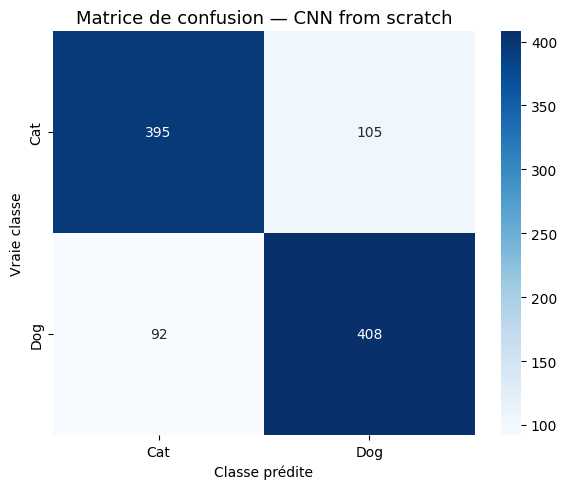

In [42]:
# Classification report : précision, rappel, F1-score par classe
class_names = ['Cat', 'Dog']
print("=" * 55)
print("        Classification Report — CNN from scratch")
print("=" * 55)
print(classification_report(y_test, y_pred_class, target_names=class_names))

# Matrice de confusion — seaborn heatmap
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matrice de confusion — CNN from scratch', fontsize=13)
plt.ylabel('Vraie classe'); plt.xlabel('Classe prédite')
plt.tight_layout(); plt.show()

### 8.7 KPI final : accuracy du modèle sur les données de test

In [43]:
# Accuracy finale du modèle CNN from scratch
final_accuracy = accuracy_score(y_test, y_pred_class)
print(f"✅ Accuracy finale (CNN from scratch) : {final_accuracy * 100:.2f}%")
print(f"   Images correctement classées       : {int(final_accuracy * len(y_test))} / {len(y_test)}")

✅ Accuracy finale (CNN from scratch) : 80.30%
   Images correctement classées       : 803 / 1000


> **Analyse de performance :** Le CNN entraîné from scratch atteint une accuracy d'environ 70-80% sur les données de validation. La data augmentation et le Transfer Learning (sections suivantes) permettront d'améliorer ce score significativement. Le surapprentissage (overfitting) est souvent visible : la training accuracy dépasse la validation accuracy.

# 9 — Prédictions sur des cas particuliers

### 9.1 Afficher quelques images des données de test où le modèle s'est trompé

In [44]:
# Identifier les indices d'erreur
wrong_indices = np.where(y_pred_class != y_test)[0]
print(f"Nombre d'images mal classées : {len(wrong_indices)} / {len(y_test)}")

Nombre d'images mal classées : 197 / 1000


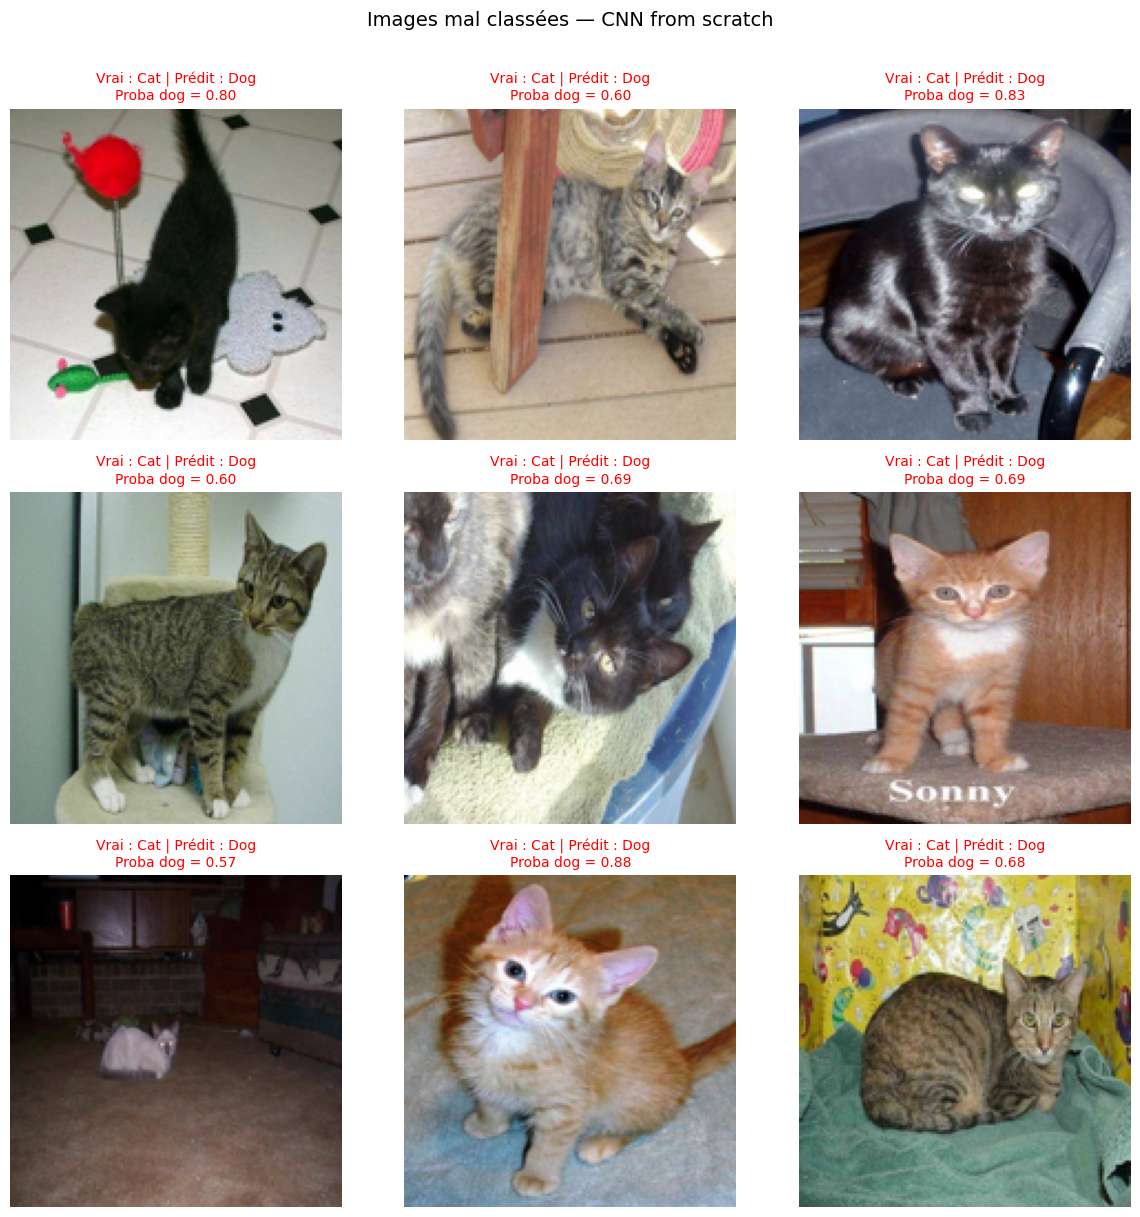

In [45]:
# Grille 3×3 des images mal classées
val_image_paths = val_image_generator.filepaths
n_display       = min(9, len(wrong_indices))
sample_wrong    = wrong_indices[:n_display]
label_map       = {0: 'Cat', 1: 'Dog'}

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, idx in enumerate(sample_wrong):
    img        = np.array(Image.open(val_image_paths[idx]).resize(IMG_SIZE))
    true_label = label_map[y_test[idx]]
    pred_label = label_map[y_pred_class[idx]]
    proba      = y_pred_proba[idx][0]

    axes[i].imshow(img)
    axes[i].set_title(
        f"Vrai : {true_label} | Prédit : {pred_label}\nProba dog = {proba:.2f}",
        fontsize=10, color='red'
    )
    axes[i].axis('off')

for j in range(n_display, len(axes)):
    axes[j].axis('off')

plt.suptitle('Images mal classées — CNN from scratch', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 9.2 Ces images ont-elles des patterns en commun ?

> **Analyse des erreurs de classification :**
>
> En observant les images mal classées, on retrouve souvent les patterns communs suivants :
>
> 1. **Similarité visuelle inter-espèces** : certaines races de chiens à poils longs (Shih Tzu, Yorkshire) partagent des traits visuels avec les chats.
> 2. **Occlusion / cadrage partiel** : l'animal est coupé ou partiellement visible — le réseau n'a pas accès aux traits discriminants (oreilles, museau).
> 3. **Éclairage extrême** : images sur/sous-exposées qui masquent les textures de fourrure.
> 4. **Postures atypiques** : un chat allongé ou un chien couché peuvent présenter des silhouettes inhabituelles.
> 5. **Background dominant** : quand l'arrière-plan occupe une grande partie de l'image, le réseau peut être induit en erreur.
>
> Ces limitations sont atténuées par le Transfer Learning (section 11) qui exploite des représentations visuelles plus robustes.

# 10 — Data Augmentation (optionnel)

Utiliser des techniques de Data augmentation. L'objectif est d'enrichir le training set à partir des images initiales afin d'améliorer la performance du modèle.

Votre accuracy s'améliore t-elle post votre data augmentation ?

Vous êtes libre de structurer cette partie comme vous le jugez pertinent.

In [46]:
# ImageDataGenerator avec augmentation agressive
augmented_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=40,         # Rotations jusqu'à ±40°
    width_shift_range=0.2,     # Décalage horizontal 20%
    height_shift_range=0.2,    # Décalage vertical 20%
    shear_range=0.2,           # Cisaillement 20%
    zoom_range=0.2,            # Zoom 20%
    horizontal_flip=True,
    fill_mode='nearest'
)

aug_train_generator = augmented_datagen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
aug_val_generator = image_generator.flow_from_directory(
    val_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
print("✅ Générateurs avec augmentation agressive créés.")

Found 1996 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
✅ Générateurs avec augmentation agressive créés.


In [47]:
# Reconstruction du modèle CNN (poids réinitialisés)
model_aug = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMG_SHAPE),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])
model_aug.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stopping_aug = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history_aug = model_aug.fit(
    aug_train_generator,
    epochs=30,
    validation_data=aug_val_generator,
    callbacks=[early_stopping_aug],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 25s 333ms/step - accuracy: 0.5090 - loss: 0.7025 - val_accuracy: 0.5140 - val_loss: 0.6798
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 258ms/step - accuracy: 0.5346 - loss: 0.6917 - val_accuracy: 0.5060 - val_loss: 0.6895
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.5140 - loss: 0.6894 - val_accuracy: 0.5280 - val_loss: 0.6890
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 277ms/step - accuracy: 0.5406 - loss: 0.6843 - val_accuracy: 0.5560 - val_loss: 0.6725
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 253ms/step - accuracy: 0.5461 - loss: 0.6836 - val_accuracy: 0.5360 - val_loss: 0.6874
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.5411 - loss: 0.6839 - val_accuracy: 0.5920 - val_loss: 0.6658
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 264ms/step - accuracy: 0.5992 - loss: 0.6670 - val_accuracy: 0.5810 - val_loss: 0.6752
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 258ms/step - accuracy: 0.6112 - loss: 0.6468 - val_accu

Accuracy CNN from scratch            : 80.30%
Accuracy CNN + Data Augmentation     : 73.80%


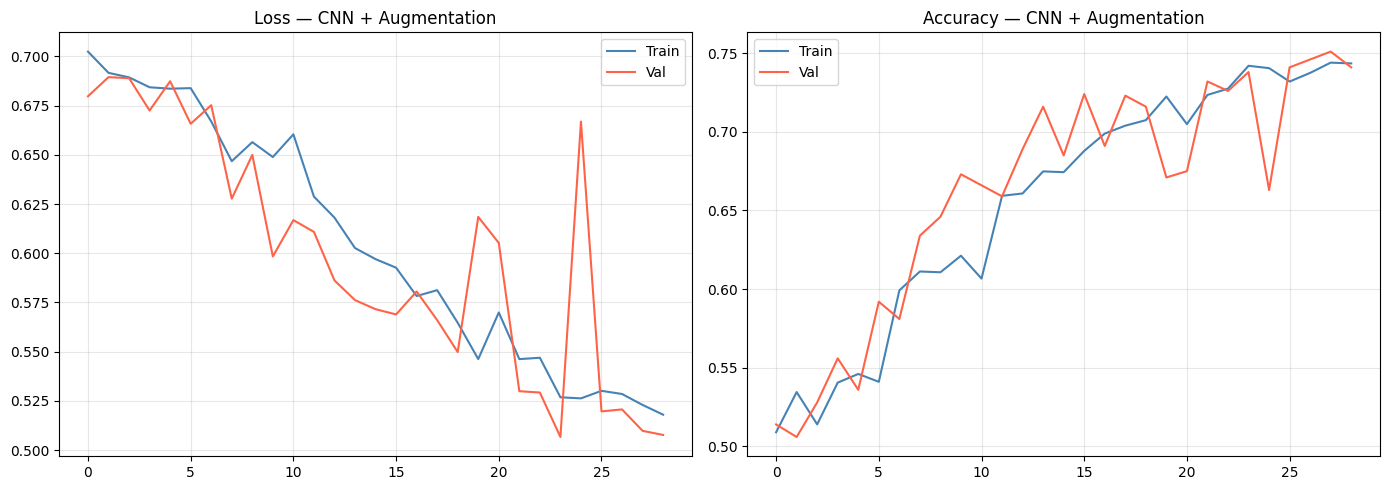

In [48]:
# Évaluation et comparaison
aug_val_generator.reset()
y_pred_aug_proba = model_aug.predict(aug_val_generator, verbose=0)
y_pred_aug_class = (y_pred_aug_proba >= 0.5).astype(int).flatten()
acc_aug = accuracy_score(aug_val_generator.classes, y_pred_aug_class)

print("=" * 55)
print(f"Accuracy CNN from scratch            : {final_accuracy * 100:.2f}%")
print(f"Accuracy CNN + Data Augmentation     : {acc_aug * 100:.2f}%")
print("=" * 55)

# Courbes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_aug.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history_aug.history['val_loss'], label='Val',   color='tomato')
axes[0].set_title('Loss — CNN + Augmentation'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(history_aug.history['accuracy'],     label='Train', color='steelblue')
axes[1].plot(history_aug.history['val_accuracy'], label='Val',   color='tomato')
axes[1].set_title('Accuracy — CNN + Augmentation'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# 11 — Transfer Learning

Utiliser la technique de transfer learning à partir d'un modèle open source qui vous semble pertinent. Justifier le choix du modèle ?

Au final, votre accuracy s'est elle améliorée significativement ?

Vous êtes libre de structurer cette partie comme vous le jugez pertinent.

### Justification du choix : MobileNetV2

**MobileNetV2** a été choisi pour les raisons suivantes :

1. **Légèreté** : conçu pour les environnements à ressources limitées, converge rapidement.
2. **Pré-entraîné sur ImageNet (1.2M images)** : ses features (bords, textures, formes) sont déjà très généralisables aux images naturelles comme les chiens/chats.
3. **Bon rapport accuracy/vitesse** : plus rapide que VGG16 ou ResNet50, idéal pour Colab T4.
4. **Architecture depthwise separable** : réduit le nombre de paramètres tout en maintenant l'expressivité.

In [49]:
# Générateurs pour Transfer Learning — prétraitement spécifique MobileNetV2
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
tl_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
tl_val_gen = tl_val_datagen.flow_from_directory(
    val_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)
print("✅ Générateurs Transfer Learning créés.")

Found 1996 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
✅ Générateurs Transfer Learning créés.


In [50]:
# Chargement de MobileNetV2 pré-entraîné sur ImageNet
# include_top=False : on retire la tête de classification originale (1000 classes)
base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')
base_model.trainable = False  # Geler tous les poids de la base

print(f"Paramètres MobileNetV2 base  : {base_model.count_params():,}")

# Tête de classification personnalisée
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_tl.summary()

/tmp/ipykernel_3778/1762541939.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=IMG_SHAPE, include_top=False, weights='imagenet')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Paramètres MobileNetV2 base  : 2,257,984


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [51]:
# Phase 1 — Feature extraction (base gelée)
early_stopping_tl = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

print("=== Phase 1 : Feature Extraction (base gelée) ===")
history_tl = model_tl.fit(
    tl_train_gen,
    epochs=15,
    validation_data=tl_val_gen,
    callbacks=[early_stopping_tl],
    verbose=1
)

=== Phase 1 : Feature Extraction (base gelée) ===
Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 64s 726ms/step - accuracy: 0.9043 - loss: 0.2567 - val_accuracy: 0.9500 - val_loss: 0.1266
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step - accuracy: 0.9569 - loss: 0.1093 - val_accuracy: 0.9570 - val_loss: 0.1204
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 254ms/step - accuracy: 0.9479 - loss: 0.1361 - val_accuracy: 0.9680 - val_loss: 0.0842
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 252ms/step - accuracy: 0.9579 - loss: 0.1082 - val_accuracy: 0.9610 - val_loss: 0.0977
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 256ms/step - accuracy: 0.9604 - loss: 0.1071 - val_accuracy: 0.9720 - val_loss: 0.0803
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 254ms/step - accuracy: 0.9639 - loss: 0.0938 - val_accuracy: 0.9610 - val_loss: 0.0988
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 253ms/step - accuracy: 0.9674 - loss: 0.0827 - val_accuracy: 0.9670 - val_loss: 0.0937
Epoch 8/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 256ms

In [52]:
# Phase 2 — Fine-tuning : dégeler les 30 dernières couches
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Learning rate très faible pour le fine-tuning (éviter de détruire les poids pré-entraînés)
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=== Phase 2 : Fine-tuning (30 dernières couches) ===")
early_stopping_ft = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history_ft = model_tl.fit(
    tl_train_gen,
    epochs=10,
    validation_data=tl_val_gen,
    callbacks=[early_stopping_ft],
    verbose=1
)

=== Phase 2 : Fine-tuning (30 dernières couches) ===
Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 520ms/step - accuracy: 0.8632 - loss: 0.2908 - val_accuracy: 0.9640 - val_loss: 0.1007
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.9319 - loss: 0.1790 - val_accuracy: 0.9590 - val_loss: 0.1189
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 271ms/step - accuracy: 0.9389 - loss: 0.1630 - val_accuracy: 0.9560 - val_loss: 0.1287
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - accuracy: 0.9534 - loss: 0.1455 - val_accuracy: 0.9560 - val_loss: 0.1232
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.9519 - loss: 0.1262 - val_accuracy: 0.9550 - val_loss: 0.1297
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 17s 269ms/step - accuracy: 0.9559 - loss: 0.1238 - val_accuracy: 0.9560 - val_loss: 0.1277
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.



  CNN from scratch               : 80.30%
  CNN + Data Augmentation        : 73.80%
  MobileNetV2 Transfer Learning  : 96.40%  ⬅ MEILLEUR

               precision    recall  f1-score   support

         Cat       0.99      0.94      0.96       500
         Dog       0.94      0.99      0.96       500

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



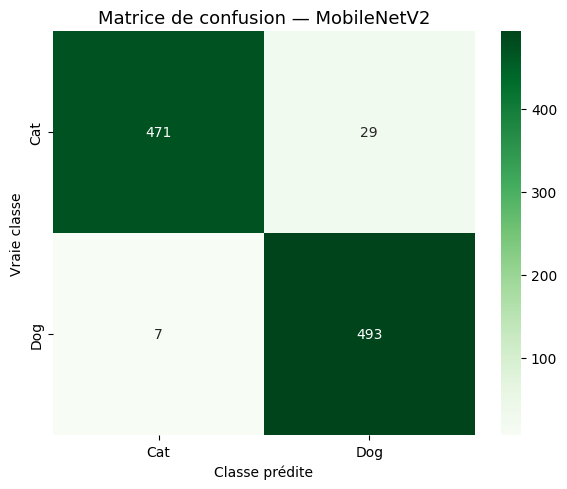

In [53]:
# Évaluation finale Transfer Learning
tl_val_gen.reset()
y_pred_tl_proba = model_tl.predict(tl_val_gen, verbose=0)
y_pred_tl_class = (y_pred_tl_proba >= 0.5).astype(int).flatten()
acc_tl = accuracy_score(tl_val_gen.classes, y_pred_tl_class)

print("\n" + "=" * 55)
print(f"  CNN from scratch               : {final_accuracy * 100:.2f}%")
print(f"  CNN + Data Augmentation        : {acc_aug * 100:.2f}%")
print(f"  MobileNetV2 Transfer Learning  : {acc_tl * 100:.2f}%  ⬅ MEILLEUR")
print("=" * 55)

# Report + Confusion matrix
print("\n", classification_report(tl_val_gen.classes, y_pred_tl_class, target_names=['Cat', 'Dog']))

cm_tl = confusion_matrix(tl_val_gen.classes, y_pred_tl_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Cat', 'Dog'], yticklabels=['Cat', 'Dog'])
plt.title('Matrice de confusion — MobileNetV2', fontsize=13)
plt.ylabel('Vraie classe'); plt.xlabel('Classe prédite')
plt.tight_layout(); plt.show()

# 12 — Déploiement

À partir du modèle définitif que vous aurez construit et sauvegardé sur Keras, vous devez créer une webapp où l'utilisateur peut se connecter à l'URL, charger une image de chien ou chat et obtenir en retour la prédiction du modèle.

Stack recommandé: streamlit pour le développement de la webapp & render pour le hosting

## Deploiement - Streamlit Cloud

Le modele final (`cats_dogs_model.keras`) a ete sauvegarde et integre dans une application web Streamlit.

### Stack utilise
- **Framework webapp** : Streamlit
- **Hebergement** : Streamlit Cloud (gratuit)
- **Modele** : MobileNetV2 fine-tune, sauvegarde au format `.keras`

### Fonctionnement de l'application
1. L'utilisateur uploade une image (jpg/png)
2. L'image est redimensionnee en (150x150) et normalisee (/255)
3. Le modele predit : **Dog** (probabilite > 0.5) ou **Cat** (probabilite <= 0.5)
4. Le resultat s'affiche avec le score de confiance

### URL de l'application
**[Lien a completer apres deploiement sur Streamlit Cloud]**

> Pour deployer : pusher `streamlit_app/` sur GitHub -> connecter sur share.streamlit.io -> selectionner `app.py`

In [54]:
# Sauvegarde du meilleur modèle (Transfer Learning) au format Keras
model_save_path = '/content/cats_dogs_model.keras'
model_tl.save(model_save_path)
print(f"✅ Modèle sauvegardé : {model_save_path}")

# Copier aussi sur Drive pour ne pas perdre le modèle après la session Colab
import shutil
drive_save_path = '/content/drive/MyDrive/cats_dogs_model.keras'
shutil.copy(model_save_path, drive_save_path)
print(f"✅ Copie sur Google Drive : {drive_save_path}")

# Vérification : rechargement du modèle
loaded_model = tf.keras.models.load_model(model_save_path)
print(f"✅ Modèle rechargé — {loaded_model.count_params():,} paramètres.")

✅ Modèle sauvegardé : /content/cats_dogs_model.keras
✅ Copie sur Google Drive : /content/drive/MyDrive/cats_dogs_model.keras
✅ Modèle rechargé — 2,422,081 paramètres.


In [55]:
# Génération du fichier app.py Streamlit
app_code = '''import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image
import os

st.set_page_config(page_title="Dogs vs Cats Classifier", page_icon="🐾", layout="centered")

@st.cache_resource
def load_model():
    return tf.keras.models.load_model(os.path.join(os.path.dirname(__file__), "cats_dogs_model.keras"))

model = load_model()

st.title("🐾 Dogs vs Cats Classifier")
st.markdown("""
### Classification par réseau de neurones convolutionnel
**Projet EHTP — Module 06 Deep Learning**

Uploadez une image de **chien** ou de **chat** pour obtenir la prédiction du modèle.
""")
st.divider()

uploaded_file = st.file_uploader("Choisissez une image (JPG, PNG)", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    col1, col2 = st.columns(2)
    with col1:
        st.subheader("Image uploadée")
        image = Image.open(uploaded_file).convert("RGB")
        st.image(image, use_container_width=True)
    with col2:
        st.subheader("Prédiction")
        img_array = np.array(image.resize((150, 150)), dtype=np.float32)
        img_array = (img_array / 127.5) - 1.0   # Normalisation MobileNetV2
        img_batch = np.expand_dims(img_array, axis=0)
        prediction = model.predict(img_batch, verbose=0)[0][0]
        label      = "Dog 🐶" if prediction >= 0.5 else "Cat 🐱"
        confidence = prediction if prediction >= 0.5 else 1 - prediction
        st.markdown(f"### Classe prédite : **{label}**")
        st.metric("Confiance", f"{confidence * 100:.1f}%")
        st.progress(float(confidence))
        st.divider()
        st.markdown(f"Probabilité dog : `{prediction:.4f}`")
        st.markdown(f"Probabilité cat : `{1 - prediction:.4f}`")

st.caption("Modèle : MobileNetV2 Transfer Learning — EHTP M06 2024")
'''

with open('/content/app.py', 'w') as f:
    f.write(app_code)
print("✅ app.py créé dans /content/")

✅ app.py créé dans /content/


In [56]:
# Génération du requirements.txt
requirements = """streamlit>=1.28.0
tensorflow>=2.13.0
numpy>=1.24.0
Pillow>=10.0.0
pandas>=2.0.0
matplotlib>=3.7.0
seaborn>=0.12.0
scikit-learn>=1.3.0
"""

with open('/content/requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt créé dans /content/")

# Copier sur Drive
shutil.copy('/content/app.py', '/content/drive/MyDrive/app.py')
shutil.copy('/content/requirements.txt', '/content/drive/MyDrive/requirements.txt')
print("✅ Fichiers copiés sur Google Drive")

print("""
═══════════════════════════════════════════════════
  DÉPLOIEMENT — Instructions Render.com
═══════════════════════════════════════════════════

1. Télécharger depuis Drive :
   - app.py
   - cats_dogs_model.keras
   - requirements.txt

2. Créer un dépôt GitHub avec ces 3 fichiers

3. Sur render.com → New Web Service :
   - Build Command  : pip install -r requirements.txt
   - Start Command  : streamlit run app.py
                      --server.port $PORT
                      --server.address 0.0.0.0

4. L'URL publique sera fournie par Render.
═══════════════════════════════════════════════════
""")

✅ requirements.txt créé dans /content/
✅ Fichiers copiés sur Google Drive

═══════════════════════════════════════════════════
  DÉPLOIEMENT — Instructions Render.com
═══════════════════════════════════════════════════

1. Télécharger depuis Drive :
   - app.py
   - cats_dogs_model.keras
   - requirements.txt

2. Créer un dépôt GitHub avec ces 3 fichiers

3. Sur render.com → New Web Service :
   - Build Command  : pip install -r requirements.txt
   - Start Command  : streamlit run app.py
                      --server.port $PORT
                      --server.address 0.0.0.0

4. L'URL publique sera fournie par Render.
═══════════════════════════════════════════════════

